# 📈 Algorithmic Trading Strategy using Moving Average Crossover

## Objective
To design and evaluate a rule-based trading strategy using moving average crossover and compare its performance with a buy-and-hold strategy.

This project demonstrates how trading signals can be generated using historical price data and how their effectiveness can be evaluated using financial metrics.

In [2]:
!pip -q install yfinance

In [11]:
!pip -q install yfinance

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use('seaborn-v0_8')

## Data Collection

- Stock: RELIANCE.NS
- Time Period: 2020–2024
- Data Source: Yahoo Finance
- Data Used: Daily Closing Price

In [12]:
stock = 'RELIANCE.NS'

data = yf.download(stock, start='2020-01-01', end='2024-01-01')
data = data[['Close']]

data.head()

/tmp/ipykernel_2802/162823639.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,RELIANCE.NS
Date,
2020-01-01,675.324158
2020-01-02,686.821228
2020-01-03,687.648804
2020-01-06,671.700745
2020-01-07,682.034546


## Moving Average Calculation

We calculate:
- 20-day moving average (short-term trend)
- 50-day moving average (long-term trend)

In [5]:
data['MA20'] = data['Close'].rolling(20).mean()
data['MA50'] = data['Close'].rolling(50).mean()

## Trading Strategy Logic

- BUY when MA20 > MA50
- SELL when MA20 < MA50

In [6]:
data['Signal'] = 0

data.loc[data['MA20'] > data['MA50'], 'Signal'] = 1
data.loc[data['MA20'] < data['MA50'], 'Signal'] = -1

## Returns Calculation

- Market Returns: Daily percentage change
- Strategy Returns: Returns based on trading signals

In [7]:
data['Returns'] = data['Close'].pct_change()

data['Strategy_Returns'] = data['Returns'] * data['Signal'].shift(1)

## Performance Comparison

We compare:
- Buy & Hold strategy
- Moving Average strategy

In [8]:
data['Cumulative_Market'] = (1 + data['Returns']).cumprod()
data['Cumulative_Strategy'] = (1 + data['Strategy_Returns']).cumprod()

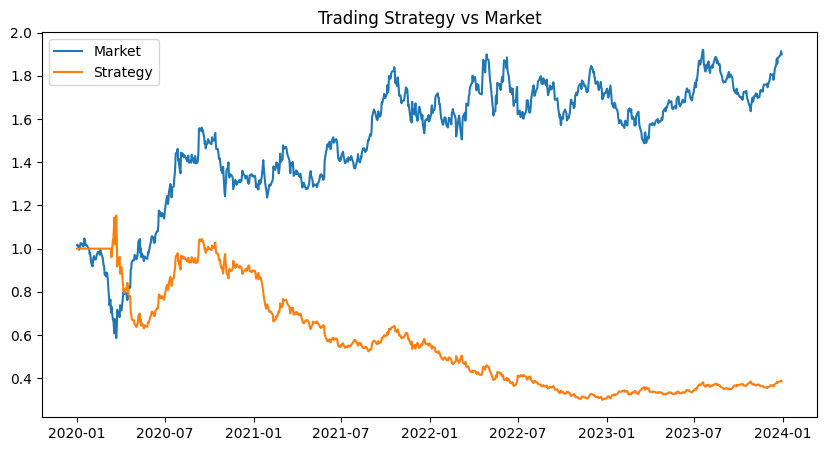

In [9]:
plt.figure(figsize=(10,5))
plt.plot(data['Cumulative_Market'], label='Market')
plt.plot(data['Cumulative_Strategy'], label='Strategy')

plt.legend()
plt.title('Trading Strategy vs Market')
plt.show()

## Performance Metrics

We evaluate performance using Sharpe Ratio, which measures risk-adjusted return.

In [10]:
sharpe = (data['Strategy_Returns'].mean() / data['Strategy_Returns'].std()) * np.sqrt(252)
print("Sharpe Ratio:", sharpe)

Sharpe Ratio: -0.6651133228095464
